In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

published_data = pd.read_csv("/content/drive/MyDrive/patent_published.csv")
granted_data = pd.read_csv("/content/drive/MyDrive/patent_granted.csv")

<ipython-input-2-75d9aba60f95>:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  published_data = pd.read_csv("/content/drive/MyDrive/patent_published.csv")


In [ ]:
published_data.head()

,Unnamed: 0,PUBLICATION_NUMBER,PUBLICATION_DATE,IPO_LOCATION,APPLICATION_TYPE_DESC,APPLICATION_NUMBER,DATE_OF_FILING,TITLE_OF_INVENTION,FIELD_OF_INVENTION,NO_OF_PAGES,NO_OF_CLAIMS
0,0,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6439/DELNP/2011,24/08/2011,SYSTEM FOR NONINVASIVE DETERMINATION OF ALCOHO...,BIOTECHNOLOGY,88,32
1,1,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6442/DELNP/2011,24/08/2011,ELECTRODE PLATE FOR A BATTERY,ELECTRICAL,21,43
2,2,36/2016,31/08/2016,Delhi,PCT NATIONAL PHASE APPLICATION,6498/DELNP/2011,25/08/2011,"""SUBSTITUTED 1,1,3,3-TETRAOXIDOBENZO[D][1,3,2]...",CHEMISTRY,161,159
3,3,36/2016,31/08/2016,Delhi,CONVENTION APPLICATION,652/DEL/2009,31/03/2009,"""PARTITION-FREE MULTI-SOCKET MEMORY SYSTEM ARC...",ELECTRONICS,32,30
4,4,36/2016,31/08/2016,Delhi,CONVENTION APPLICATION,658/DEL/2015,11/03/2015,PROCESS FOR WELDING PIPE CONNECTINS FOR HIGH T...,MECHANICAL,16,10


In [ ]:
granted_data.head()

,PUBLICATION_NUMBER,PUBLICATION_DATE,IPO_LOCATION,APPLICATION_TYPE_DESC,APPLICATION_NUMBER,DATE_OF_FILING,TITLE_OF_INVENTION,FIELD_OF_INVENTION,NO_OF_PAGES,NO_OF_CLAIMS
0,50/2016,02/12/2016,Chennai,PCT NATIONAL PHASE APPLICATION,1010/CHENP/2008,29/02/2008,A TIME-BASED COEXISTENCE METHOD FOR WIRELESS C...,ELECTRONICS,25,22
1,50/2016,02/12/2016,Kolkata,CONVENTION APPLICATION,108/KOL/2009,20/01/2009,MULTI-SPEED TRANSAXLE FOR A FRONT WHEEL DRIVE ...,MECHANICAL,26,21
2,50/2016,02/12/2016,Chennai,CONVENTION APPLICATION,1471/CHE/2009,23/06/2009,INJECTION MOLD AND MOLDING METHOD FOR RESIN MO...,MECHANICAL,27,12
3,50/2016,02/12/2016,Delhi,PCT NATIONAL PHASE APPLICATION,1762/DELNP/2003,28/10/2003,"""PROCESS FOR THE PREPARATION OF AZOXYSTROBIN A...",CHEMISTRY,18,10
4,50/2016,02/12/2016,Kolkata,PCT NATIONAL PHASE APPLICATION,1777/KOLNP/2010,17/05/2010,PROCESS FOR PREPARING TUBULYSINS,CHEMISTRY,38,12


In [ ]:
published_data['PUBLICATION_DATE'] = pd.to_datetime(published_data['PUBLICATION_DATE'], dayfirst=True, errors='coerce')
granted_data['PUBLICATION_DATE'] = pd.to_datetime(granted_data['PUBLICATION_DATE'], dayfirst=True, errors='coerce')

In [ ]:
#Set 'publication date' as index
published_data.set_index('PUBLICATION_DATE', inplace=True)
granted_data.set_index('PUBLICATION_DATE', inplace=True)

In [ ]:
# Weekly count of published patents
published_weekly = published_data.resample('W').size().reset_index()
published_weekly.columns = ['Week_Start_Date', 'Published_Count']

# Weekly count of granted patents
granted_weekly = granted_data.resample('W').size().reset_index()
granted_weekly.columns = ['Week_Start_Date', 'Granted_Count']

In [ ]:
print(published_weekly.head())
print()
print(granted_weekly.head())

  Week_Start_Date  Published_Count
0      2016-01-03              515
1      2016-01-10              212
2      2016-01-17              491
3      2016-01-24              451
4      2016-01-31              290

  Week_Start_Date  Granted_Count
0      2016-01-03            182
1      2016-01-10            130
2      2016-01-17             98
3      2016-01-24             73
4      2016-01-31            160


In [ ]:
# Merge on Week_Start_Date to align published and granted counts
weekly_data = pd.merge(published_weekly, granted_weekly, on='Week_Start_Date', how='outer').sort_values('Week_Start_Date')

# Fill any missing values (e.g., weeks where only published or granted existed)
weekly_data.fillna(0, inplace=True)

# Optional: Convert counts to integers
weekly_data[['Published_Count', 'Granted_Count']] = weekly_data[['Published_Count', 'Granted_Count']].astype(int)


In [ ]:
weekly_data.head()

,Week_Start_Date,Published_Count,Granted_Count
0,2016-01-03,515,182
1,2016-01-10,212,130
2,2016-01-17,491,98
3,2016-01-24,451,73
4,2016-01-31,290,160


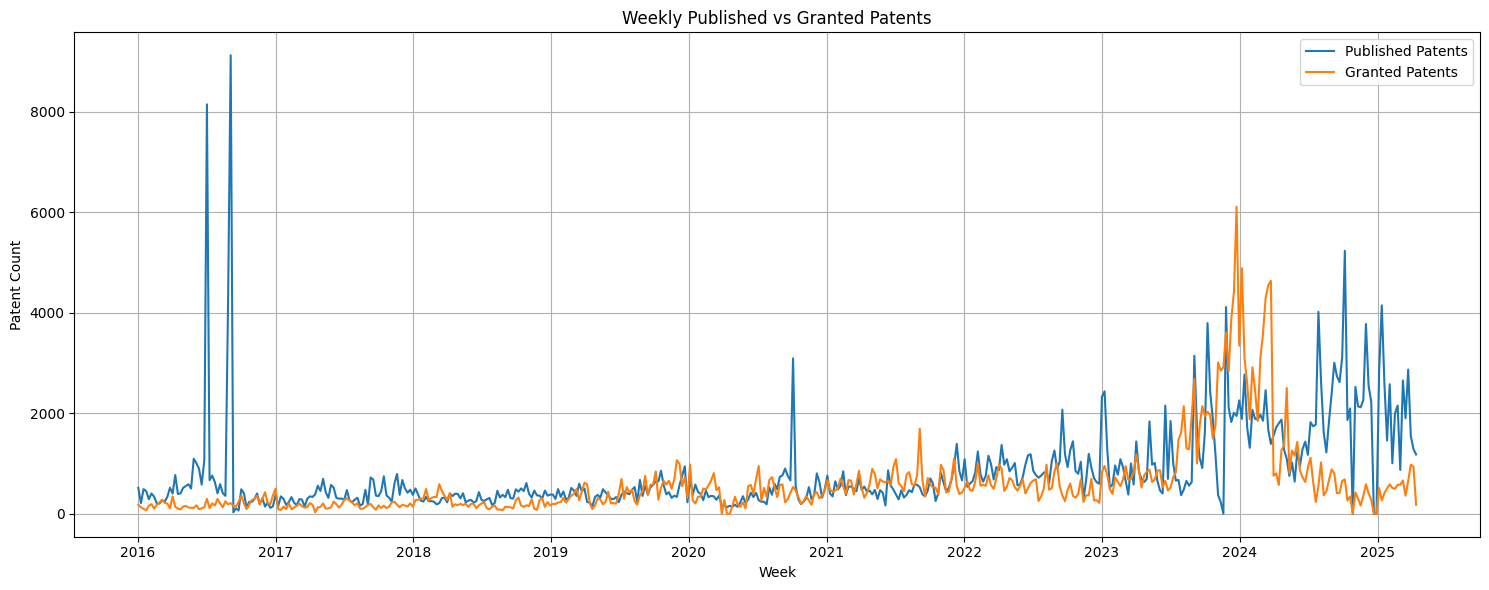

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(weekly_data['Week_Start_Date'], weekly_data['Published_Count'], label='Published Patents')
plt.plot(weekly_data['Week_Start_Date'], weekly_data['Granted_Count'], label='Granted Patents')
plt.xlabel('Week')
plt.ylabel('Patent Count')
plt.title('Weekly Published vs Granted Patents')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
granted_weekly['Week_Start_Date'] = pd.to_datetime(granted_weekly['Week_Start_Date'])
granted_weekly.set_index('Week_Start_Date', inplace=True)
granted_ts = granted_weekly['Granted_Count']

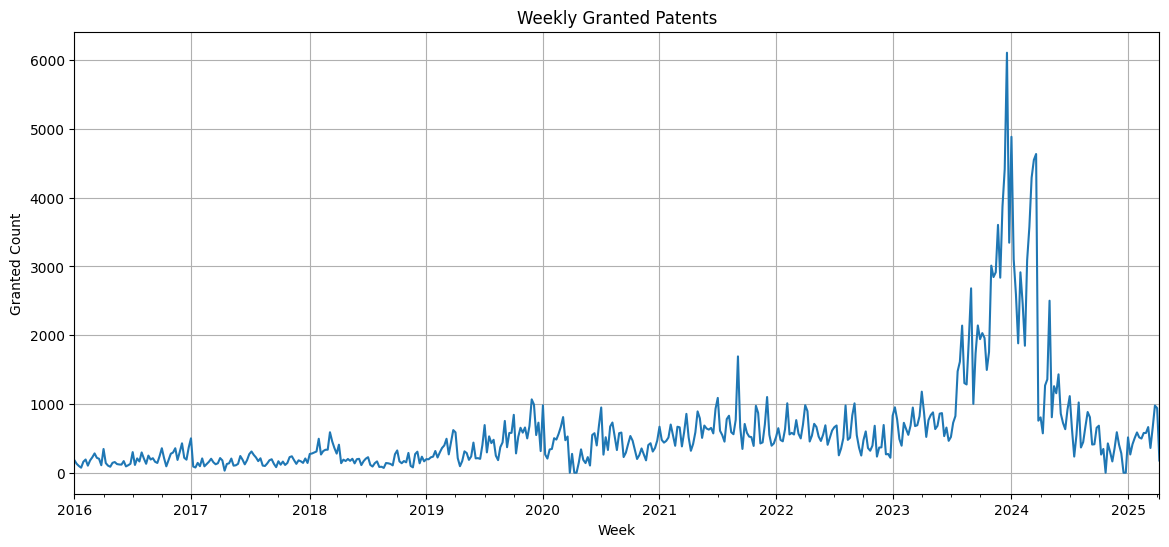

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
granted_ts.plot()
plt.title("Weekly Granted Patents")
plt.xlabel("Week")
plt.ylabel("Granted Count")
plt.grid(True)
plt.show()


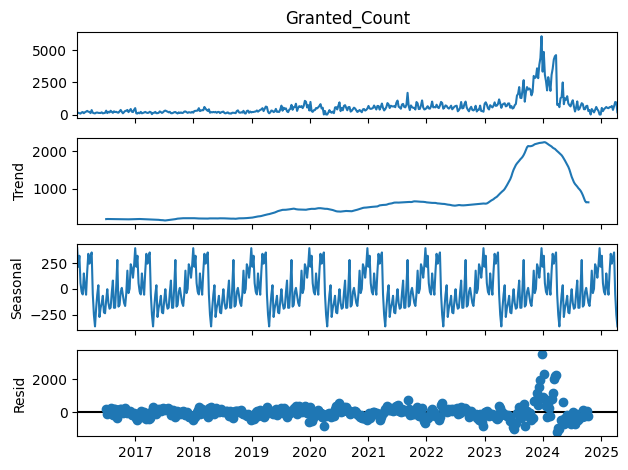

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(granted_ts, model='additive', period=52)  # Assuming weekly data, period = 52 weeks per year

# Plot the decomposed components
decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')

check_stationarity(granted_ts)

ADF Statistic: -3.186486110556204
p-value: 0.020780363562835302
Stationary


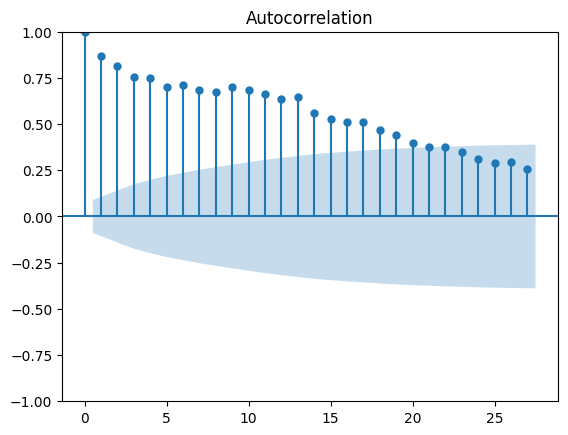

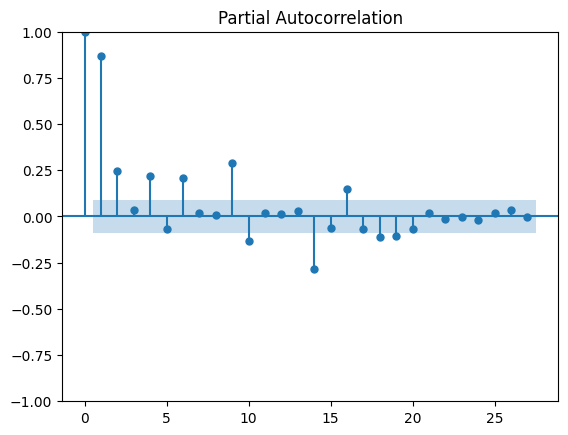

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for published patent data
plot_acf(granted_ts)
plot_pacf(granted_ts)
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    granted_ts,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 52)
)
results = model.fit()
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                     SARIMAX Results                                      
Dep. Variable:                      Granted_Count   No. Observations:                  485
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood               -3197.298
Date:                            Fri, 02 May 2025   AIC                           6404.597
Time:                                    10:24:37   BIC                           6424.950
Sample:                                01-03-2016   HQIC                          6412.632
                                     - 04-13-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.006    166.565      0.000       0.988       1.011
ma.L1         -0.3683      0.019   

In [ ]:
forecast_steps = 52
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

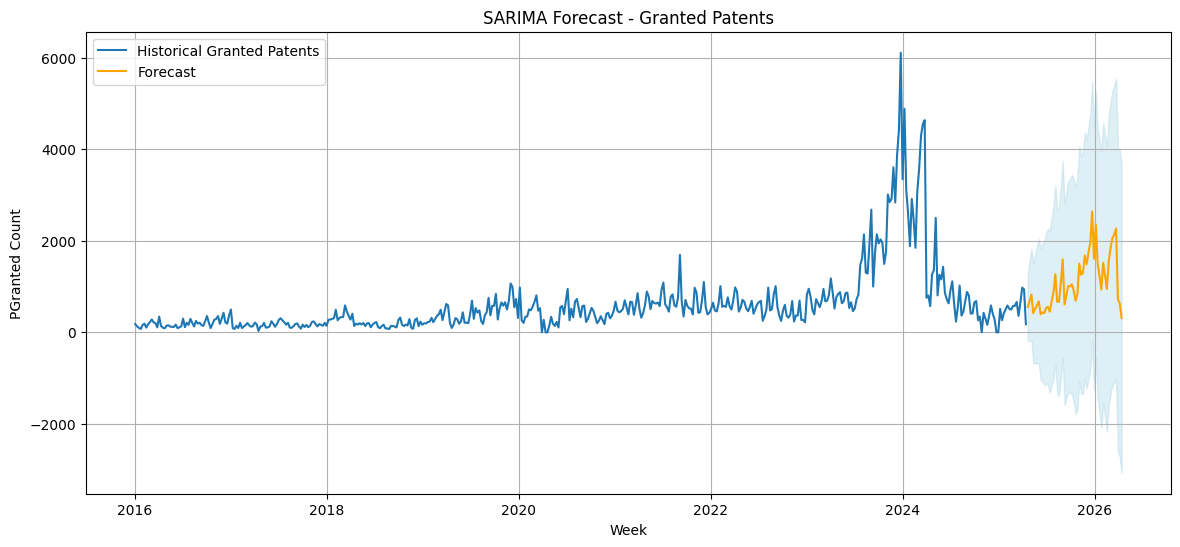

In [ ]:
# Plotting the forecast
plt.figure(figsize=(14, 6))
plt.plot(granted_ts, label='Historical Granted Patents')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='orange')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='lightblue', alpha=0.4)
plt.title("SARIMA Forecast - Granted Patents")
plt.xlabel("Week")
plt.ylabel("PGranted Count")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values from the historical data for comparison
actual_values = granted_ts[-forecast_steps:]

# Predicted values (forecast mean) for the same period
predicted_values = forecast_mean

# Calculate errors
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 784.3852521842529
Mean Squared Error (MSE): 909029.0978891046


In [ ]:
# --- Outlier Detection and Handling (Simple IQR method) ---
Q1 = granted_ts.quantile(0.25)
Q3 = granted_ts.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = granted_ts[(granted_ts < lower_bound) | (granted_ts > upper_bound)]
print("\nDetected Outliers:")
print(outliers)


Detected Outliers:
Week_Start_Date
2021-09-05    1692
2023-07-23    1476
2023-07-30    1615
2023-08-06    2140
2023-08-27    1941
2023-09-03    2682
2023-09-17    1736
2023-09-24    2142
2023-10-01    1943
2023-10-08    2031
2023-10-15    1959
2023-10-22    1495
2023-10-29    1757
2023-11-05    3012
2023-11-12    2846
2023-11-19    2916
2023-11-26    3605
2023-12-03    2837
2023-12-10    3871
2023-12-17    4417
2023-12-24    6109
2023-12-31    3346
2024-01-07    4886
2024-01-14    3104
2024-01-21    2596
2024-01-28    1882
2024-02-04    2915
2024-02-11    2462
2024-02-18    1847
2024-02-25    3091
2024-03-03    3578
2024-03-10    4292
2024-03-17    4550
2024-03-24    4636
2024-04-28    1358
2024-05-05    2502
2024-06-02    1431
Name: Granted_Count, dtype: int64


In [ ]:
median_val = granted_ts.median()
granted_ts_cleaned = granted_ts.copy()
granted_ts_cleaned[(granted_ts_cleaned < lower_bound) | (granted_ts_cleaned > upper_bound)] = median_val

In [ ]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')
    return p_value

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    granted_ts_cleaned,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 52)
)
results = model.fit()
print(results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      Granted_Count   No. Observations:                  485
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood               -2906.482
Date:                            Fri, 02 May 2025   AIC                           5822.964
Time:                                    10:29:44   BIC                           5843.318
Sample:                                01-03-2016   HQIC                          5830.999
                                     - 04-13-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9600      0.016     59.694      0.000       0.928       0.991
ma.L1         -0.7182      0.031   

In [ ]:
forecast_steps = 52
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values from the historical data for comparison
actual_values = granted_ts_cleaned[-forecast_steps:]

# Predicted values (forecast mean) for the same period
predicted_values = forecast_mean

# Calculate errors
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)

# Print the evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 140.58486451217553
Mean Squared Error (MSE): 35118.01589576019


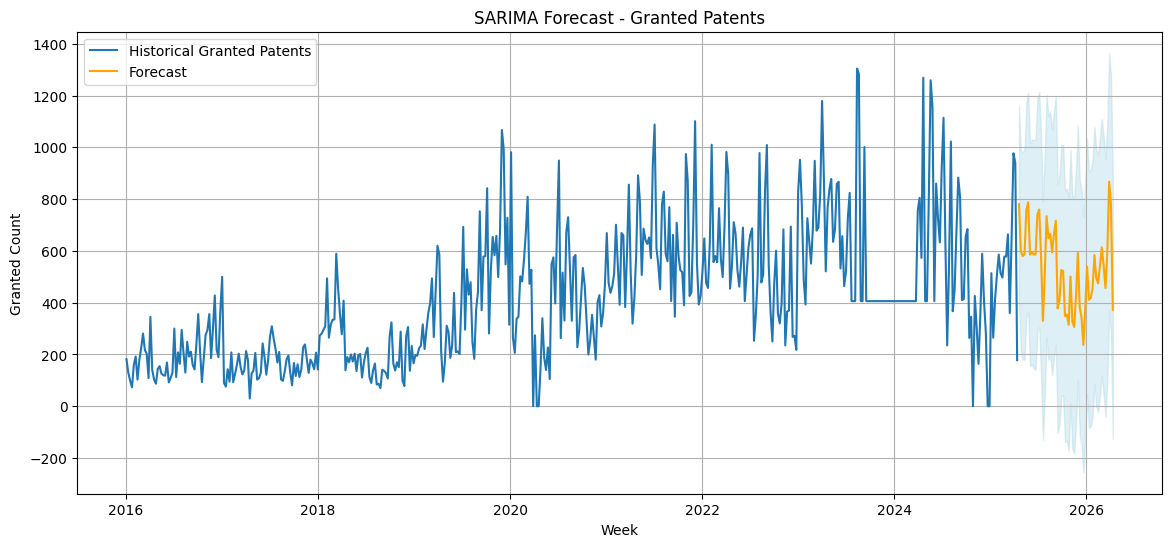

In [ ]:
# Plot the forecast
plt.figure(figsize=(14, 6))
plt.plot(granted_ts_cleaned, label='Historical Granted Patents')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='orange')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='lightblue', alpha=0.4)
plt.title("SARIMA Forecast - Granted Patents")
plt.xlabel("Week")
plt.ylabel("Granted Count")
plt.legend()
plt.grid(True)
plt.show()